# BDGDM test using colorectal cancer (CRC) public data

Running inference in two configurations:
- single mode (e.g. tumour type);
- subtype mode (running model on two tumour subtypes and perform results comparison (subtype reviring))

In [1]:
from cmdstanpy import CmdStanModel
from bdgdm import load_example_data, fit_one_gene_bdgdm, BDGDMConfig
from bdgdm.preprocessing import prepare_gene_data
from bdgdm.plot_fit import plot_copy_number_fit, plot_ppc_mean, plot_ppc_variance, plot_ppc_density
from bdgdm.plot_prior_posterior import plot_prior_vs_posterior
from bdgdm import plot_classification 

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from typing import Any, Sequence

import arviz as az
import xarray as xr

/opt/anaconda3/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## 1. Compile stan models and load example dataset

In [5]:
model_single = CmdStanModel(stan_file="../bdgdm/stan/bdgdm_single.stan")
model_subtype = CmdStanModel(stan_file="../bdgdm/stan/bdgdm_subtype.stan")

Load example CRC data

In [7]:
gene_df = load_example_data()
gene_df.head()

,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,ACVR1B,CRC.SW.U0001.T,7593,2,MSS,0.41,3.8,1.293201
1,ACVR1B,CRC.SW.U0002.T,5003,2,MSS,0.37,3.3,1.024008
2,ACVR1B,CRC.SW.U0004.T,4994,2,MSS,0.58,3.2,1.169870
3,ACVR1B,CRC.SW.U0030.T,6231,2,MSS,0.59,2.2,1.290047
4,ACVR1B,CRC.SW.U0066.T,2908,2,MSS,0.41,1.9,0.971163


Select one tumour subtype (MSS or MSI) and one gene and perfom their quick exploration

In [9]:
gene_df_single = (gene_df.loc[(gene_df["gene"] == "BRAF") & (gene_df["subtype"] == "MSS")]
    .copy()
    .reset_index(drop=True)
)

gene_df_single["subtype"] = "all_samples"
gene_df_single.head()

,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,BRAF,CRC.SW.U0001.T,3100,2,all_samples,0.41,3.8,1.293201
1,BRAF,CRC.SW.U0002.T,2913,3,all_samples,0.37,3.3,1.024008
2,BRAF,CRC.SW.U0004.T,2028,2,all_samples,0.58,3.2,1.169870
3,BRAF,CRC.SW.U0030.T,2008,2,all_samples,0.59,2.2,1.290047
4,BRAF,CRC.SW.U0066.T,2066,2,all_samples,0.41,1.9,0.971163


In [11]:
print("Number of samples:", len(gene_df_single))
print(gene_df_single["gene"].unique())
print(gene_df_single["subtype"].unique())

print(gene_df_single["copies"].describe())

Number of samples: 778
['BRAF']
['all_samples']
count    778.000000
mean       2.155527
std        0.376568
min        1.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: copies, dtype: float64


In [13]:
et = 0.15
rng_seed = 123

aneuploid_mask = (gene_df_single["copies"].sub(2).abs() > (1 - et))

aneuploid = gene_df_single.loc[aneuploid_mask]
reference = gene_df_single.loc[~aneuploid_mask]

print("Available aneuploid:", len(aneuploid))
print("Available diploid reference:", len(reference))

Available aneuploid: 123
Available diploid reference: 655


## 2. Fit one gene 

In [ ]:
Define configuration

In [15]:
test_config = BDGDMConfig(
    engine="nuts",
    chains=4,
    iter_warmup=500,
    iter_sampling=500,
    adapt_delta=0.95,
    seed=123,
    return_ppc=False,
    save_draws=False,
    save_summary=False
)

Single mode fit

In [17]:
fit_single = fit_one_gene_bdgdm(
    gene_df=gene_df_single,
    gene="BRAF",
    subtype_col="subtype",
    subtype_order=["all_samples"],
    model_single=model_single,
    model_subtype=model_subtype,
    config=test_config,
)

15:09:24 - cmdstanpy - INFO - CmdStan start processing
15:09:24 - cmdstanpy - INFO - Chain [1] start processing
15:09:24 - cmdstanpy - INFO - Chain [2] start processing
15:09:24 - cmdstanpy - INFO - Chain [3] start processing
15:09:24 - cmdstanpy - INFO - Chain [4] start processing
15:09:32 - cmdstanpy - INFO - Chain [2] done processing
15:09:33 - cmdstanpy - INFO - Chain [1] done processing
15:09:33 - cmdstanpy - INFO - Chain [4] done processing
15:09:33 - cmdstanpy - INFO - Chain [3] done processing


In [ ]:
Subtype mode fit

In [13]:
fit_subtype = fit_one_gene_bdgdm(
    gene_df=gene_df,
    gene="BRAF",
    subtype_col="subtype",
    model_single=model_single,
    model_subtype=model_subtype,
    config=test_config
)

16:57:38 - cmdstanpy - INFO - CmdStan start processing
16:57:38 - cmdstanpy - INFO - Chain [1] start processing
16:57:38 - cmdstanpy - INFO - Chain [2] start processing
16:57:38 - cmdstanpy - INFO - Chain [3] start processing
16:57:38 - cmdstanpy - INFO - Chain [4] start processing
16:58:16 - cmdstanpy - INFO - Chain [2] done processing
16:58:20 - cmdstanpy - INFO - Chain [1] done processing
16:58:21 - cmdstanpy - INFO - Chain [4] done processing
16:58:27 - cmdstanpy - INFO - Chain [3] done processing


Explore posterior fit

In [51]:
fit_subtype.posterior

{'analysis_mode': 'subtype_comparison',
 'subtype_levels': ['MSI', 'MSS'],
 'n_subtypes': 2,
 'engine': 'nuts',
 'phi_median': 32.844750000000005,
 'phi_q025': 30.1583,
 'phi_q975': 35.930242500000006,
 'b_noncancer_log_median': 7.74524,
 'b_noncancer_log_q025': 7.713791,
 'b_noncancer_log_q975': 7.77769375,
 'tumor0_lfc_median': 0.5009210305371388,
 'tumor0_lfc_q025': 0.4076101842782663,
 'tumor0_lfc_q975': 0.5982310995841075,
 'ppd_tumor': 1.0,
 'p_rope_tumor': 0.0,
 'p_pos_tumor': 1.0,
 'p_neg_tumor': 0.0,
 'delta_scaling_median': -0.286188,
 'delta_scaling_q025': -0.8819952,
 'delta_scaling_q975': 0.32360915,
 'ppd_scaling': 0.8325,
 'p_rope_scaling': 0.1735,
 'p_pos_scaling': 0.1675,
 'p_neg_scaling': 0.8325,
 'delta_dev_median': -0.120513,
 'delta_dev_q025': -0.55122475,
 'delta_dev_q975': 0.3210745749999997,
 'ppd_dev': 0.7005,
 'p_rope_dev': 0.31,
 'p_pos_dev': 0.2995,
 'p_neg_dev': 0.7005,
 'subtype_label_s1': 'MSI',
 'b0_s1_median': 7.323895,
 'b0_s1_q025': 7.2525245,
 'b0_s1

In [ ]:
Explore model fit diagnostic

In [53]:
fit_subtype.diagnostics

{'engine': 'nuts',
 'analysis_mode': 'subtype_comparison',
 'warnings': [],
 'summary_columns': ['Mean',
  'MCSE',
  'StdDev',
  '5%',
  '50%',
  '95%',
  'N_Eff',
  'N_Eff/s',
  'R_hat'],
 'rhat_column': 'R_hat',
 'bulk_ess_column': 'N_Eff',
 'tail_ess_column': None,
 'max_rhat': 1.00644,
 'min_rhat': 0.99812,
 'min_bulk_ess': 831.192,
 'min_tail_ess': nan,
 'n_chains': 4,
 'n_draws_per_chain': 500,
 'n_draws_total': 2000,
 'n_divergent': 0,
 'max_treedepth_observed': 8,
 'diagnose': 'Processing csv files: /var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/tmp16bjsleq/bdgdm_subtype3in9wika/bdgdm_subtype-20260717151654_1.csv, /var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/tmp16bjsleq/bdgdm_subtype3in9wika/bdgdm_subtype-20260717151654_2.csv, /var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/tmp16bjsleq/bdgdm_subtype3in9wika/bdgdm_subtype-20260717151654_3.csv, /var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/tmp16bjsleq/bdgdm_subtype3in9wika/bdgdm_subtype-20260717151654_4.csv\n\nChecking 

## 3. Model diagnostic 

Available posterior variables: ['b0_mean', 'b0_offset', 'b_scaling_mean', 'b_scaling_offset', 'b_dev_mean', 'b_dev_offset', 'b_noncancer_log', 'phi', 'b0', 'b_scaling', 'b_deviation', 'log_mu', 'b0_off', 'scale_off', 'dev_off', 'delta_tumor0_log', 'tumor0_fc', 'delta_scaling', 'delta_dev', 'tumor_fc_2to1', 'fracCN_2to1', 'tumor_fc_2to3', 'fracCN_2to3', 'tumor_fc_2to4', 'fracCN_2to4', 'lp_2to1', 'lp_2to3', 'lp_2to4', 'lp_scaling_2to1', 'lp_dev_2to1', 'lp_scaling_2to3', 'lp_dev_2to3', 'lp_scaling_2to4', 'lp_dev_2to4', 'cancel_index_2to1', 'cancel_index_2to3', 'cancel_index_2to4', 'y_rep', 'mu_rep']


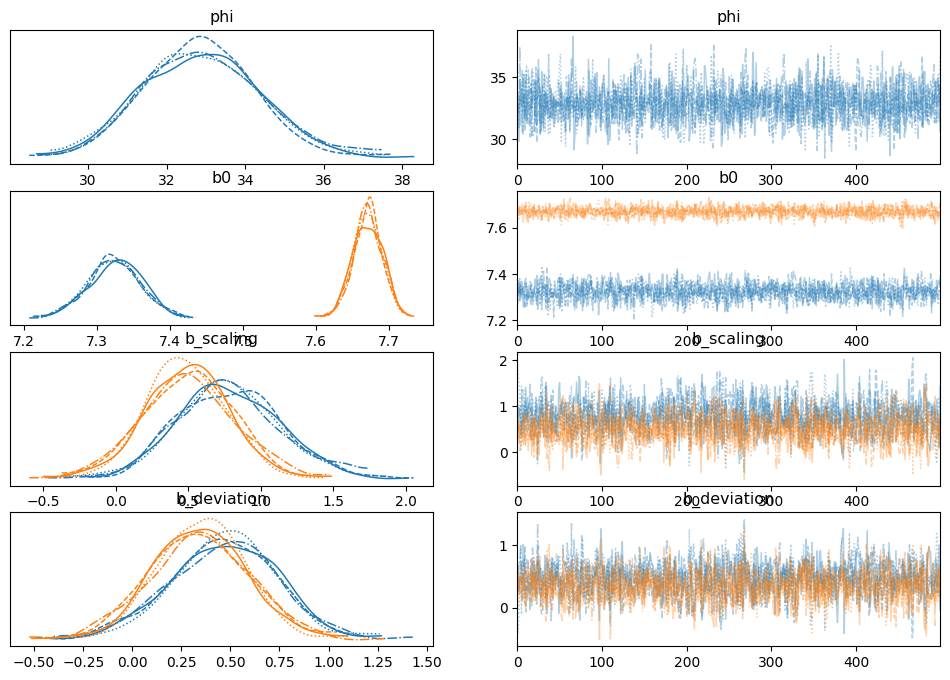

In [19]:
idata = az.from_cmdstanpy(posterior=fit_subtype.fit)
available = list(idata.posterior.data_vars)
print("Available posterior variables:", available)

az.plot_trace(
    idata,
    var_names=[
        "phi",
        "b0",
        "b_scaling",
        "b_deviation",
    ],
)

plt.show()

### Posterior predictive check (PPC)

In [17]:
processed, stan_data, metadata = prepare_gene_data(
    gene_df=gene_df,
    gene="BRAF",
    subtype_col="subtype",
    #subtype_order=["all_samples"],
    cna="all",
    et=0.15,
    min_aneup=5,
    min_unique_counts=5,
    min_cn_abs_sum=1.0,
)

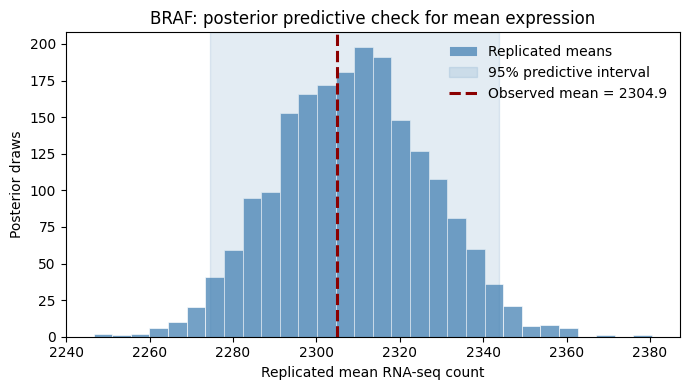

In [63]:
# PPC - Mean

fig, ax, ppc_summary = plot_ppc_mean(
    fit_subtype,
    stan_data["y"],
    gene="BRAF",
    histogram_color="steelblue",
    observed_color="darkred",
    credible_interval=0.95,
)

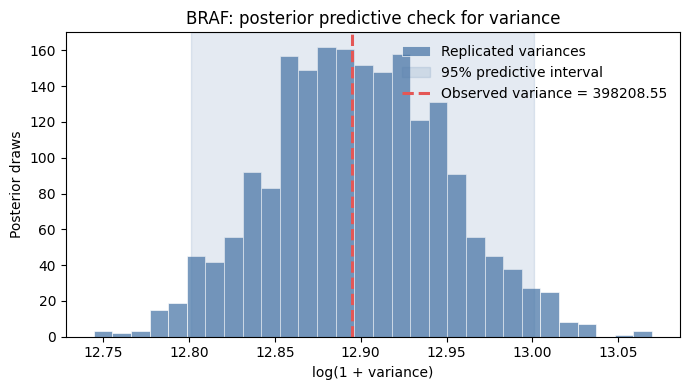

In [65]:
# PPC - Variance

fig, ax, variance_summary = plot_ppc_variance(
    fit_subtype,
    stan_data["y"],
    gene="BRAF",
    histogram_color="#4C78A8",
    observed_color="#E45756",
    credible_interval=0.95,
)

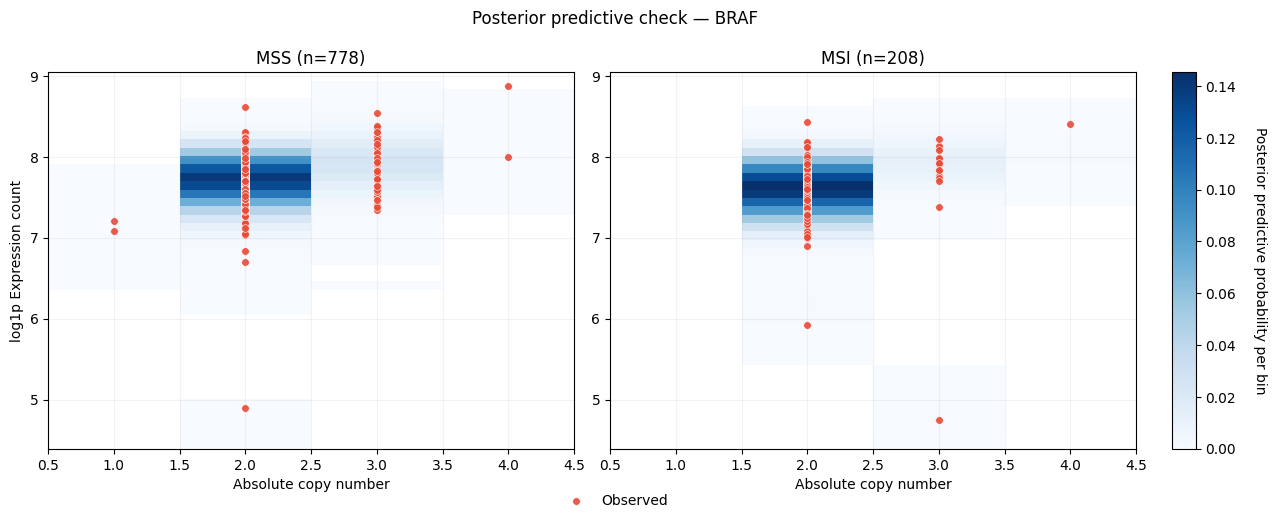

In [19]:
# PCC per subtype

fig, axes, ppc_summary = plot_ppc_density(
    fit_subtype,
    x_observed=processed["copies"],
    y_observed=stan_data["y"],
    subtype_observed=processed["subtype"],
    subtype_order=["MSS", "MSI"],
    gene="BRAF",
    transform="log1p",
    x_bins="integer",
    density_mode="probability",
    figsize=(13.5, 5.7),
)

#### Prior vs posterior

,parameter,subtype_index,subtype_label,prior_mean,prior_sd,posterior_median,posterior_q_low,posterior_q_high,credible_interval,n_draws
0,b_scaling,1,MSS,0.4,0.543139,0.765413,0.131844,1.512528,0.95,2000
1,b_scaling,2,MSI,0.4,0.543139,0.494916,-0.126856,1.084011,0.95,2000


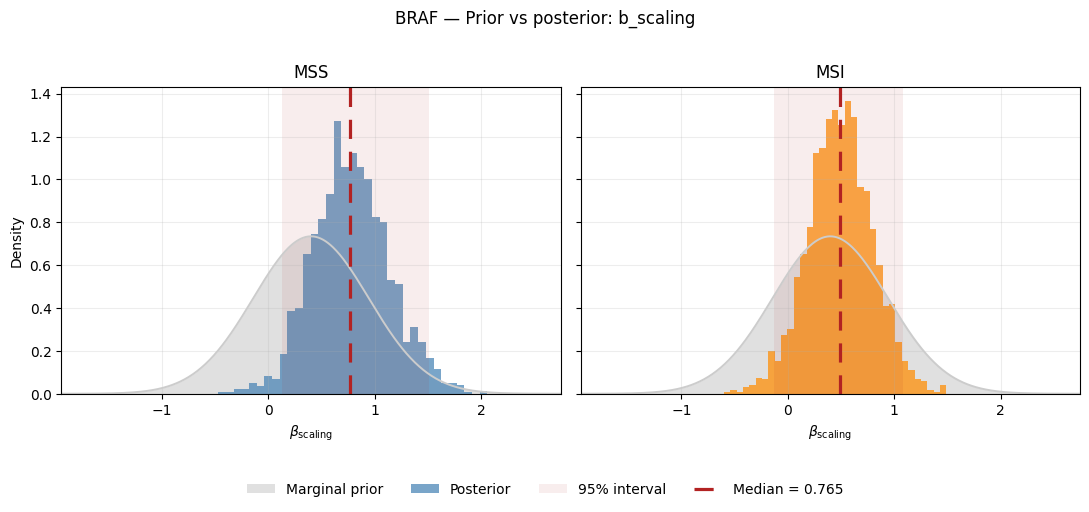

In [21]:
fig, axes, summary = plot_prior_vs_posterior(
    fit_subtype,
    parameter="b_scaling",
    subtype_labels=["MSS", "MSI"],
    gene="BRAF",
    xlabel=r"$\beta_{\mathrm{scaling}}$",
    posterior_colors=("steelblue", "darkorange"),
    credible_interval=0.95,
)

summary

,parameter,subtype_index,subtype_label,prior_mean,prior_sd,posterior_median,posterior_q_low,posterior_q_high,credible_interval,n_draws
0,b_deviation,1,MSS,0.0,0.331662,0.475808,-0.088215,0.987806,0.95,2000
1,b_deviation,2,MSI,0.0,0.331662,0.348679,-0.133707,0.814825,0.95,2000


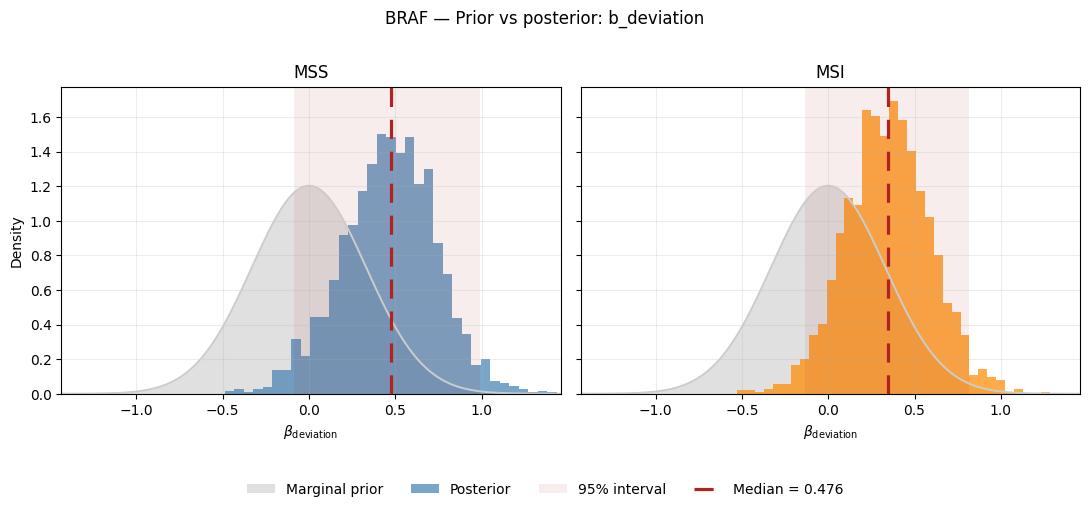

In [25]:
fig, axes, summary = plot_prior_vs_posterior(
    fit_subtype,
    parameter="b_deviation",
    subtype_labels=["MSS", "MSI"],
    gene="BRAF",
    xlabel=r"$\beta_{\mathrm{deviation}}$",
    posterior_colors=("steelblue", "darkorange"),
    credible_interval=0.95,
)

summary

#### Copy-number-expression relatioship

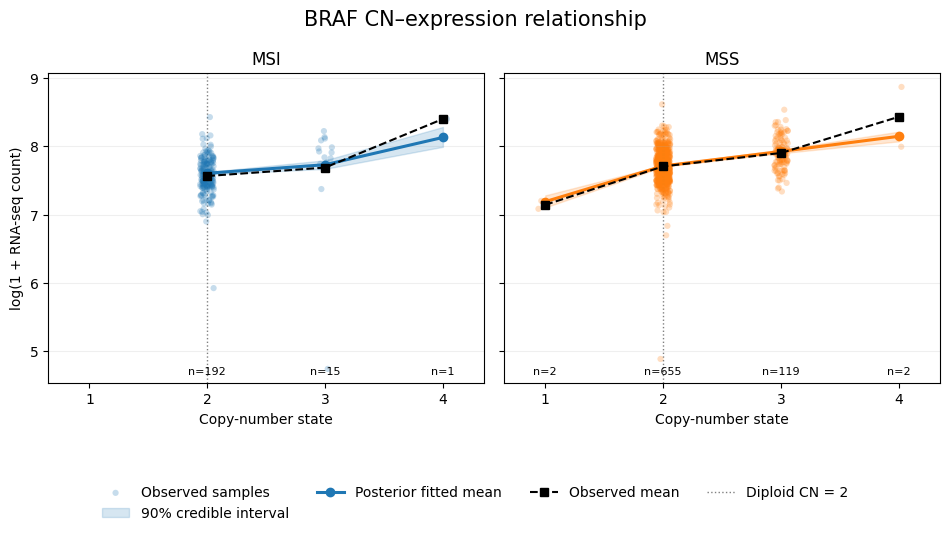

In [67]:
processed_df, stan_data, metadata = prepare_gene_data(
    gene_df=gene_df,
    gene="BRAF",
    subtype_col="subtype",
)

fig, cn_summary = plot_copy_number_fit(
    fit_subtype,
    processed_df,
    subtype_col="subtype",
    cn_col="copies",
    expr_col="expr",
    credible_interval=0.90,
)

## 4. Fit multiple genes

In [39]:
rep_genes = ["ASXL1", "SMAD4", "BCOR", "KRAS", "BRAF"]

fits_rep = {}
fit_errors = {}

for gene in rep_genes:
    print(f"Fitting {gene}...")

    try:
        result = fit_one_gene_bdgdm(
            gene_df=gene_df,
            gene=gene,
            model_single=model_single,
            model_subtype=model_subtype,
            config=test_config,
        )

        fits_rep[gene] = result

        print(
            f"Completed {gene}: "
            f"mode={result.analysis_mode}, "
            f"converged={result.diagnostics.get('converged')}"
        )

    except Exception as error:
        fit_errors[gene] = error

        print(
            f"Failed {gene}: "
            f"{type(error).__name__}: {error}"
        )

17:21:23 - cmdstanpy - INFO - CmdStan start processing
17:21:23 - cmdstanpy - INFO - Chain [1] start processing
17:21:23 - cmdstanpy - INFO - Chain [2] start processing
17:21:23 - cmdstanpy - INFO - Chain [3] start processing
17:21:23 - cmdstanpy - INFO - Chain [4] start processing


Fitting ASXL1...


17:22:07 - cmdstanpy - INFO - Chain [3] done processing
17:22:08 - cmdstanpy - INFO - Chain [4] done processing
17:22:11 - cmdstanpy - INFO - Chain [1] done processing
17:38:34 - cmdstanpy - INFO - Chain [2] done processing
17:38:35 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 2 had 499 iterations at max treedepth (99.8%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.
17:38:45 - cmdstanpy - INFO - CmdStan start processing
17:38:45 - cmdstanpy - INFO - Chain [1] start processing
17:38:45 - cmdstanpy - INFO - Chain [2] start processing
17:38:45 - cmdstanpy - INFO - Chain [3] start processing
17:38:45 - cmdstanpy - INFO - Chain [4] start processing


Completed ASXL1: mode=subtype_comparison, converged=False
Fitting SMAD4...


17:39:15 - cmdstanpy - INFO - Chain [2] done processing
17:39:16 - cmdstanpy - INFO - Chain [3] done processing
17:39:16 - cmdstanpy - INFO - Chain [1] done processing
17:39:17 - cmdstanpy - INFO - Chain [4] done processing
17:39:28 - cmdstanpy - INFO - CmdStan start processing
17:39:28 - cmdstanpy - INFO - Chain [1] start processing
17:39:28 - cmdstanpy - INFO - Chain [2] start processing
17:39:28 - cmdstanpy - INFO - Chain [3] start processing
17:39:28 - cmdstanpy - INFO - Chain [4] start processing


...

Completed BCOR: mode=subtype_comparison, converged=True
Fitting KRAS...


17:40:50 - cmdstanpy - INFO - Chain [1] done processing
17:40:51 - cmdstanpy - INFO - Chain [4] done processing
17:40:52 - cmdstanpy - INFO - Chain [3] done processing
17:40:52 - cmdstanpy - INFO - Chain [2] done processing
17:41:03 - cmdstanpy - INFO - CmdStan start processing
17:41:03 - cmdstanpy - INFO - Chain [1] start processing
17:41:03 - cmdstanpy - INFO - Chain [2] start processing
17:41:03 - cmdstanpy - INFO - Chain [3] start processing
17:41:03 - cmdstanpy - INFO - Chain [4] start processing


Completed KRAS: mode=subtype_comparison, converged=True
Fitting BRAF...


17:41:41 - cmdstanpy - INFO - Chain [2] done processing
17:41:44 - cmdstanpy - INFO - Chain [1] done processing
17:41:45 - cmdstanpy - INFO - Chain [4] done processing
17:41:51 - cmdstanpy - INFO - Chain [3] done processing


Completed BRAF: mode=subtype_comparison, converged=True


In [41]:
posterior_table = pd.DataFrame([{
    "gene": gene,
    **result.posterior,
}
    for gene, result in fits_rep.items()
    ]
)

posterior_table

,gene,analysis_mode,subtype_levels,n_subtypes,engine,phi_median,phi_q025,phi_q975,b_noncancer_log_median,b_noncancer_log_q025,...,lp_dev_2to4_s2_q975,cancel_index_2to1_s2_median,cancel_index_2to1_s2_q025,cancel_index_2to1_s2_q975,cancel_index_2to3_s2_median,cancel_index_2to3_s2_q025,cancel_index_2to3_s2_q975,cancel_index_2to4_s2_median,cancel_index_2to4_s2_q025,cancel_index_2to4_s2_q975
0,ASXL1,subtype_comparison,"[MSI, MSS]",2,nuts,22.32215,10.000000,24.669458,8.260335,1.531950,...,0.438052,0.078119,-0.428077,0.150104,-0.133545,-0.256604,0.731802,-0.156238,-0.300208,0.856153
1,SMAD4,subtype_comparison,"[MSI, MSS]",2,nuts,12.54675,11.499530,13.698647,7.427785,7.358232,...,2.082159,-7.880925,-178.822900,-2.831301,13.472550,4.840136,305.699850,15.761850,5.662602,357.645775
2,BCOR,subtype_comparison,"[MSI, MSS]",2,nuts,14.98815,13.718360,16.280123,7.801600,7.743775,...,0.407575,-0.486418,-5.550692,0.990547,0.831537,-1.693354,9.488980,0.972836,-1.981098,11.101362
3,KRAS,subtype_comparison,"[MSI, MSS]",2,nuts,18.02630,16.551053,19.591707,7.679105,7.631048,...,0.684096,-0.419406,-1.168393,-0.145050,0.716979,0.247964,1.997379,0.838812,0.290100,2.336785
4,BRAF,subtype_comparison,"[MSI, MSS]",2,nuts,32.84475,30.158300,35.930243,7.745240,7.713791,...,0.814825,-0.506509,-13.045030,0.088986,0.865883,-0.152122,22.300532,1.013020,-0.177971,26.089962


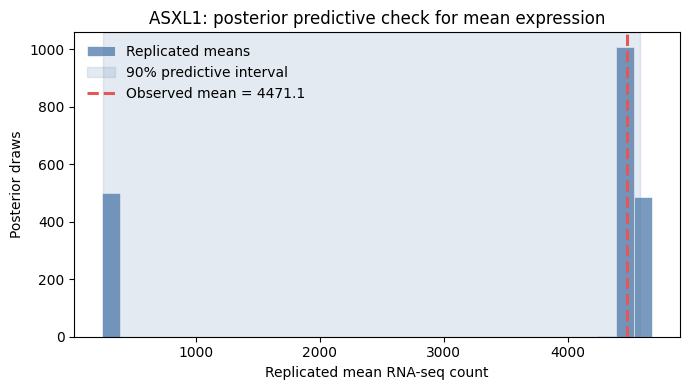

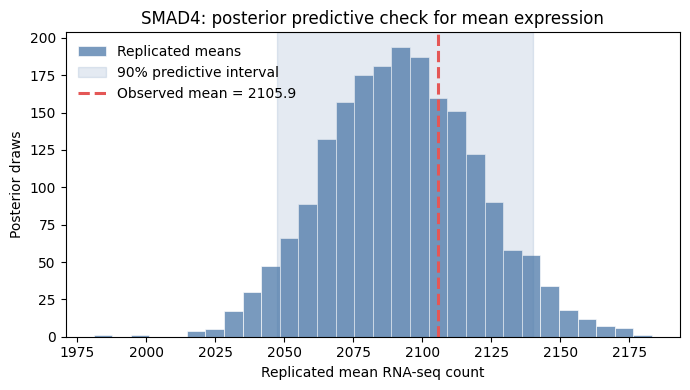

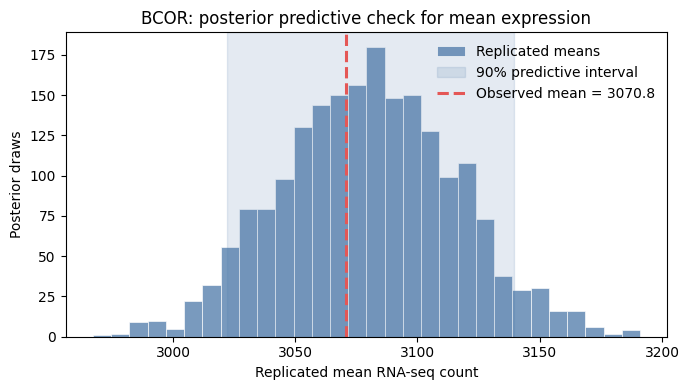

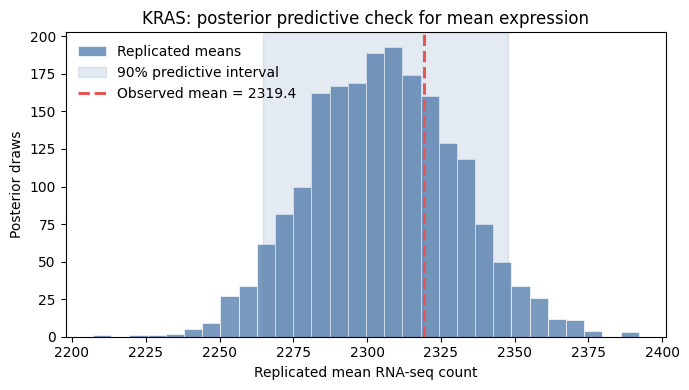

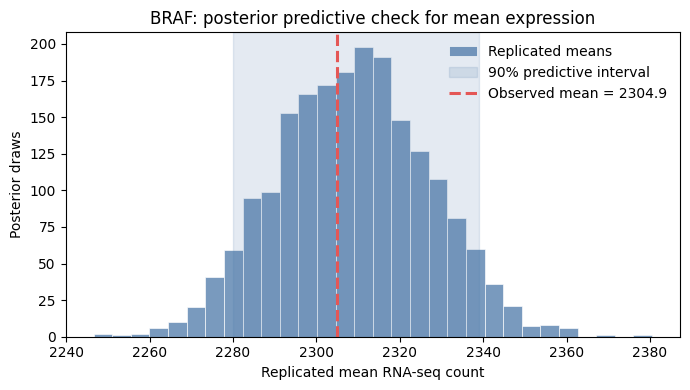

In [43]:
# Plot PPC mean for every successful gene

for gene, result in fits_rep.items():
    processed_df, stan_data, metadata = prepare_gene_data(
        gene_df=gene_df,
        gene=gene,
        subtype_col="subtype",
    )

    fig, ax, ppc_summary = plot_ppc_mean(
        result,
        stan_data["y"],
        gene=gene,
        histogram_color="#4C78A8",
        observed_color="#E45756",
        show=True,
    )

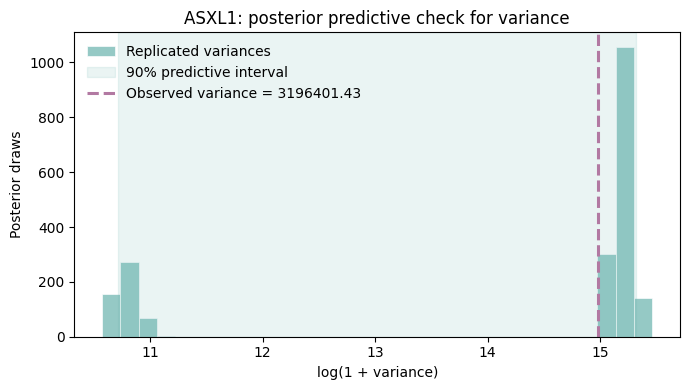

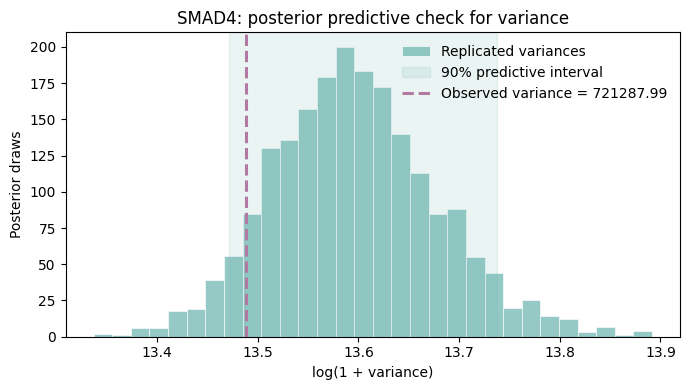

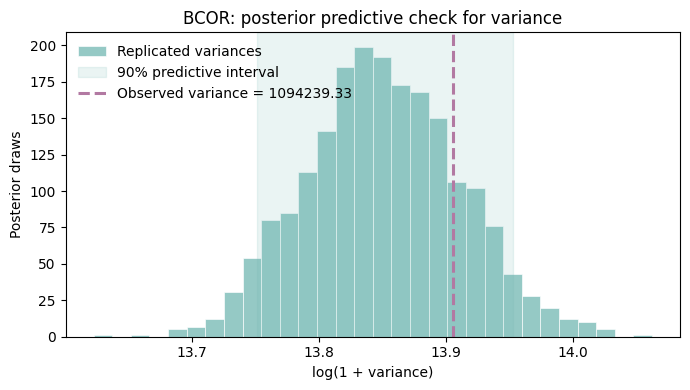

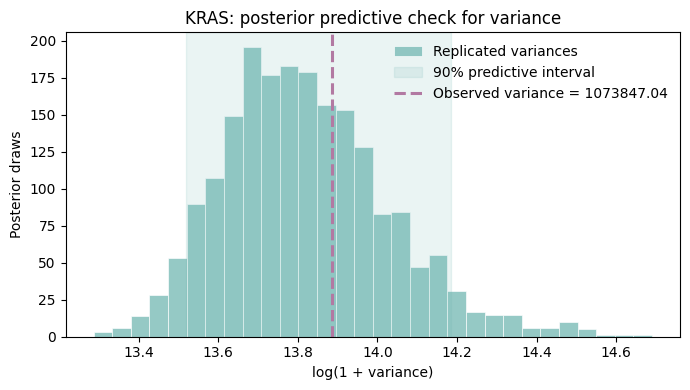

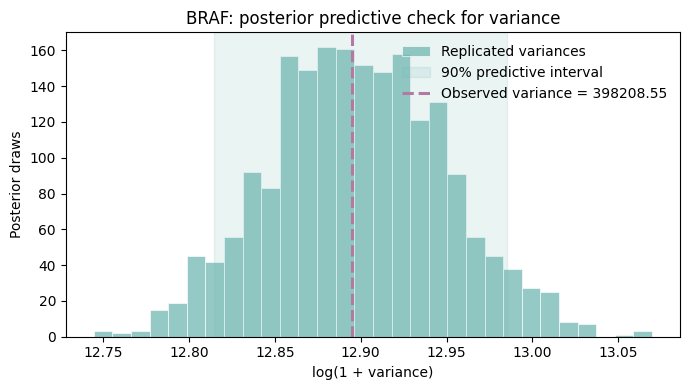

In [45]:
# Plot PPC variance for every successful gene

for gene, result in fits_rep.items():
    processed_df, stan_data, metadata = prepare_gene_data(
        gene_df=gene_df,
        gene=gene,
        subtype_col="subtype",
    )

    fig, ax, variance_summary = plot_ppc_variance(
        result,
        stan_data["y"],
        gene=gene,
        histogram_color="#72B7B2",
        observed_color="#B279A2",
        show=True,
    )

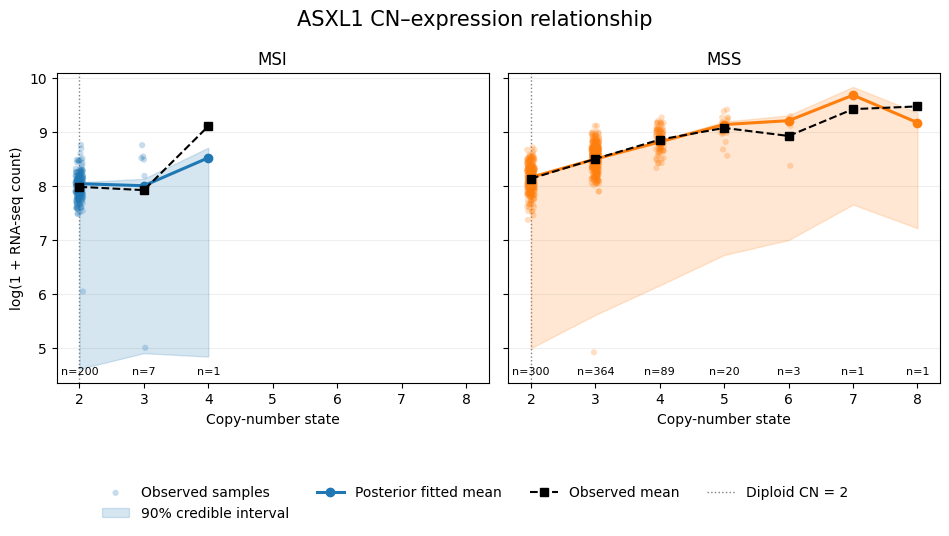

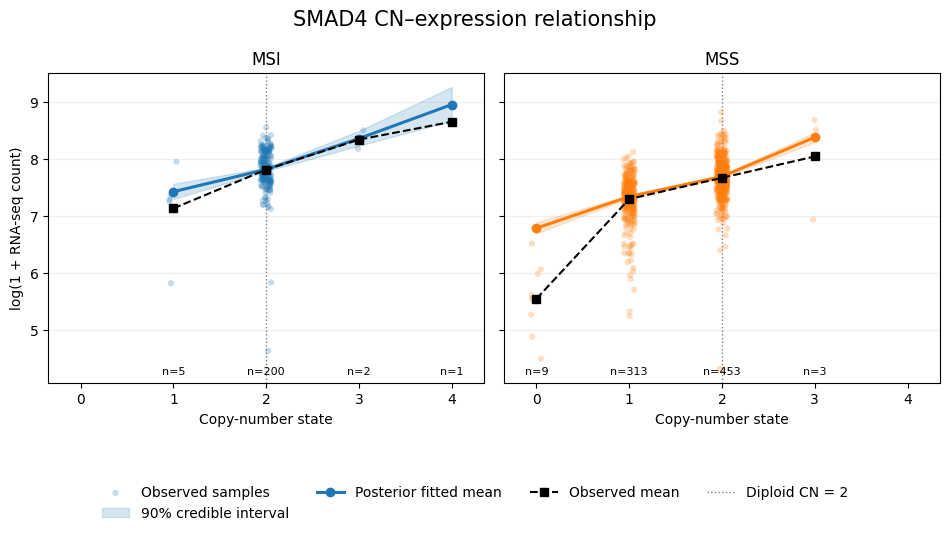

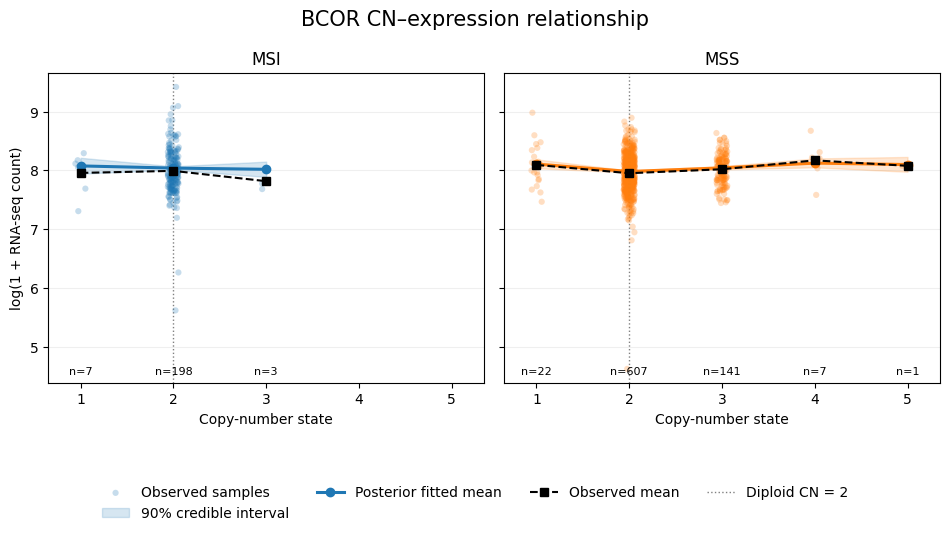

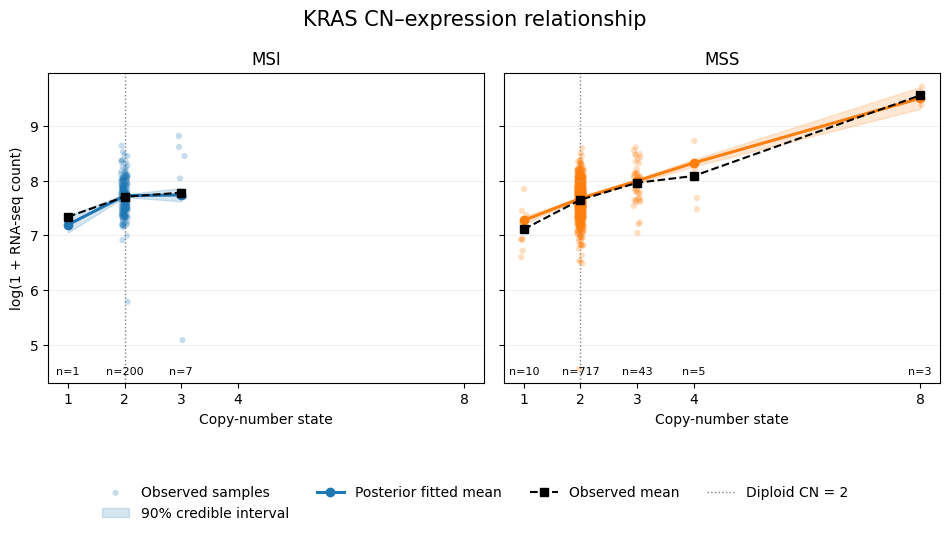

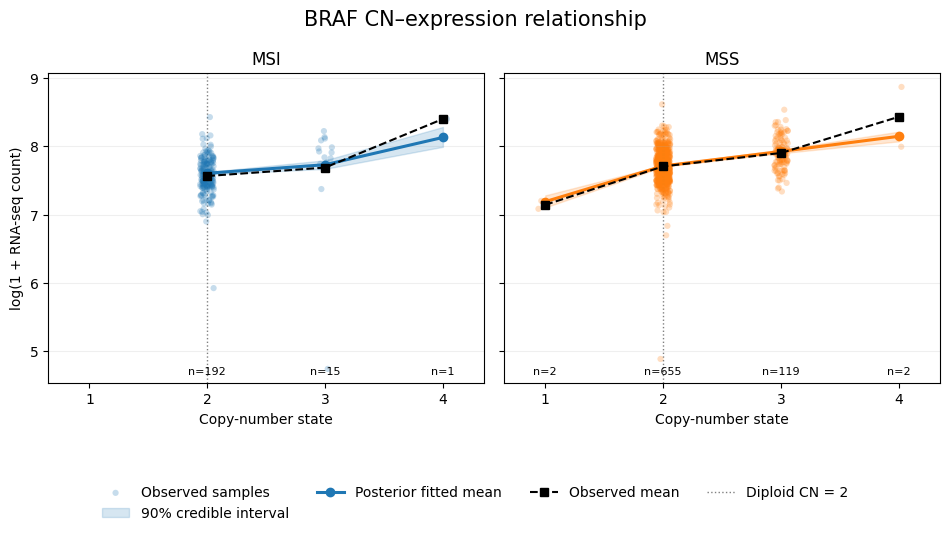

In [47]:
# Plot CN-expression relationship fit

for gene, result in fits_rep.items():
    processed_df, stan_data, metadata = prepare_gene_data(
        gene_df=gene_df,
        gene=gene,
        subtype_col="subtype",
    )

    fig, cn_summary = plot_copy_number_fit(
        result,
        processed_df,
        credible_interval=0.90,
    )

    plt.show()

## 5. Gene-dosage classification

In [49]:
from bdgdm.classify import ClassificationThresholds, classify_fit

Define classification thresholds

In [51]:
thresholds = ClassificationThresholds(
    ppd_sig=0.95,
    rope_low=0.05,
    rope_high=0.95,
    dose_prob_sensitive=0.95,
    dose_prob_insensitive=0.95,
    cancel_threshold=0.20,
    overcomp_threshold=1.00,
    hyper_threshold=0.50,
    low_cn_aneup_threshold=10,
)

In [53]:
# Single gene

classif = classify_fit(fit_subtype,
                      thresholds=thresholds)
classif

{'gene': 'BRAF',
 'status': 'ok',
 'fit_flag': 'ok',
 'analysis_mode': 'subtype_comparison',
 'N': 986,
 'n_aneup': 139,
 'cna': 'all',
 'S': 2,
 'subtype_levels': ['MSI', 'MSS'],
 'subtype_levels_str': 'MSI|MSS',
 'de_status': 'DE',
 'ppd_tumor': 1.0,
 'p_rope_tumor': 0.0,
 'tumor0_lfc_median': 0.5009210305371388,
 'tumor0_lfc_q025': 0.4076101842782663,
 'tumor0_lfc_q975': 0.5982310995841075,
 'rewiring_status': 'rewiring_uncertain',
 'scaling_rewired': False,
 'deviation_rewired': False,
 'scaling_rewiring_evidence': 'ppd_and_rope',
 'deviation_rewiring_evidence': 'ppd_and_rope',
 'ppd_scaling': 0.8325,
 'ppd_dev': 0.7005,
 'p_rope_scaling': 0.1735,
 'p_rope_dev': 0.31,
 'delta_scaling_median': -0.286188,
 'delta_scaling_q025': -0.8819952,
 'delta_scaling_q975': 0.32360915,
 'delta_dev_median': -0.120513,
 'delta_dev_q025': -0.55122475,
 'delta_dev_q975': 0.3210745749999997,
 'subtype_s1': 'MSI',
 'response_class_s1': 'HYPER',
 'response_reason_s1': 'supported_hyper_pattern',
 'respo

In [71]:
# Multiple genes

classified_df = classify_fits(fits_rep,
                             thresholds=thresholds)
classified_df

,gene,status,fit_flag,analysis_mode,N,n_aneup,cna,S,subtype_levels,subtype_levels_str,...,fracCN_2to4_median_s2,direction_probability_2to4_s2,rope_probability_2to4_s2,response_class_MSS,response_reason_MSS,response_subclass_MSS,transition_2to1_MSS,transition_2to3_MSS,transition_2to4_MSS,summary_label
0,ASXL1,ok,warn,subtype_comparison,986,486,all,2,"[MSI, MSS]",MSI|MSS,...,1.831835,1.0000,0.0000,UNC,insufficient_or_inconsistent_support,ambiguous,weak,weak,weak,"DE | rewiring_uncertain | MSI:UNC,MSS:UNC"
1,SMAD4,ok,ok,subtype_comparison,986,333,all,2,"[MSI, MSS]",MSI|MSS,...,3.738781,1.0000,0.0000,HYPER,supported_hyper_pattern,None,hyperactive,hyperactive,hyperactive,"DE-uncertain | rewired:deviation | MSI:HYPER,M..."
2,BCOR,ok,ok,subtype_comparison,986,181,all,2,"[MSI, MSS]",MSI|MSS,...,0.048768,0.2375,0.7505,DIG,all_transition_effects_small,median_based,weak,null,weak,"DE-null | rewiring_uncertain | MSI:DIG,MSS:DIG"
3,KRAS,ok,ok,subtype_comparison,986,69,all,2,"[MSI, MSS]",MSI|MSS,...,1.743296,1.0000,0.0000,HYPER,supported_hyper_pattern,None,weak,hyperactive,hyperactive,"DE-null | rewiring_uncertain | MSI:HYPER,MSS:H..."
4,BRAF,ok,ok,subtype_comparison,986,139,all,2,"[MSI, MSS]",MSI|MSS,...,0.993738,1.0000,0.0000,HYPER,supported_hyper_pattern,None,hyperactive,hyperactive,hyperactive,"DE | rewiring_uncertain | MSI:HYPER,MSS:HYPER"


In [109]:
classified_long = classification_wide_to_long(classified_df)
classified_long[
    [
        "gene",
        "subtype",
        "response_class",
        "b_scaling_median",
        "b_deviation_median",
    ]
].head()

,gene,subtype,response_class,b_scaling_median,b_deviation_median
0,ASXL1,MSI,UNC,1.650765,0.161902
1,SMAD4,MSI,HYPER,0.247078,0.988751
2,BCOR,MSI,DIG,0.109853,-0.055082
3,KRAS,MSI,HYPER,0.960900,0.475025
4,BRAF,MSI,HYPER,0.765413,0.475808


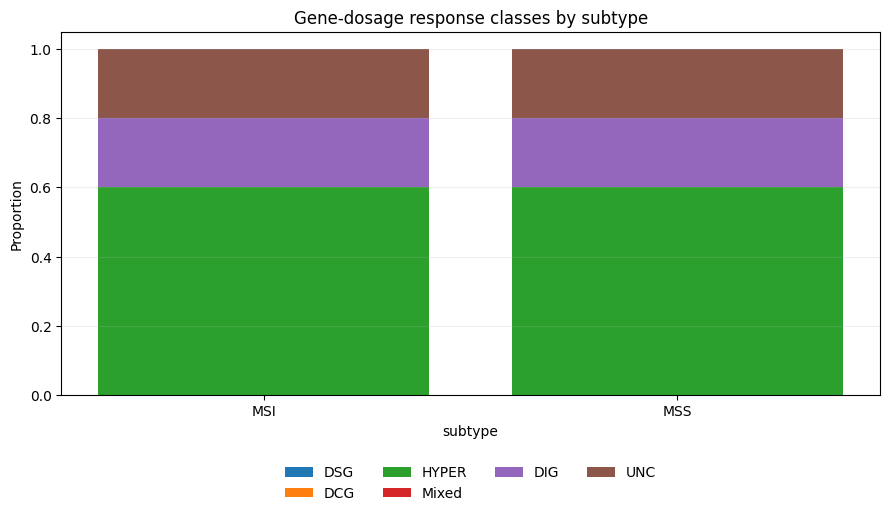

In [125]:
fig, ax, class_summary = plot_class_distribution(
    classified_long,
    classification_col="response_class",
    group_col="subtype",
    normalize=True,
    title="Gene-dosage response classes by subtype",
)

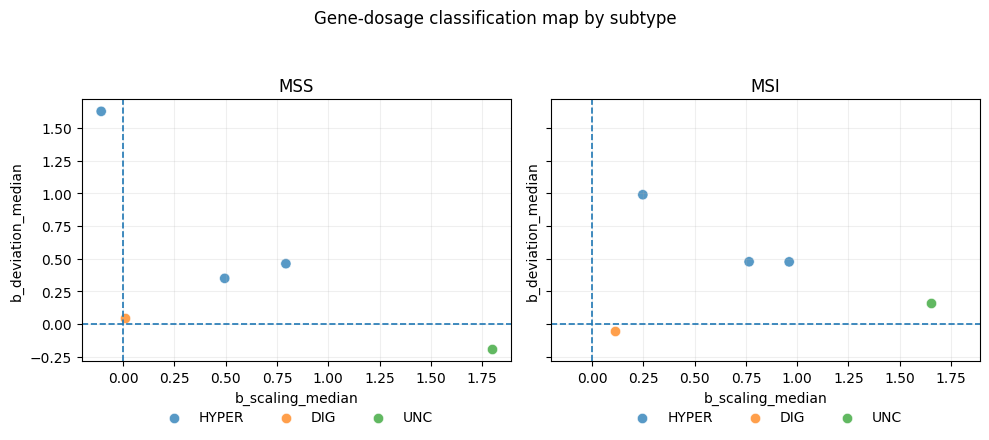

In [131]:
subtype_order = ["MSS", "MSI"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5),
    sharex=True,
    sharey=True,
)

map_summaries = []

for ax, subtype_name in zip(
    axes,
    subtype_order,
):
    subtype_data = classified_long.loc[
        classified_long["subtype"].eq(
            subtype_name
        )
    ]

    _, _, subtype_summary = (
        plot_classification_parameter_map(
            subtype_data,
            scaling_col="b_scaling_median",
            deviation_col="b_deviation_median",
            classification_col="response_class",
            gene_col="gene",
            subtype_col="subtype",
            title=subtype_name,
            ax=ax,
        )
    )

    map_summaries.append(
        subtype_summary
    )

fig.suptitle(
    "Gene-dosage classification map by subtype",
    y=0.98,
)

fig.tight_layout(
    rect=(0, 0.08, 1, 0.94)
)